# Tobacco Mortality Forecasting Using Machine Learning

**Objective:** Build a leakage-free machine learning model that forecasts **next-year smoking-related mortality rate** using historical trends in smoking prevalence and hospital admissions.

**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn

**Key ML practices used:** time-aware validation, leakage prevention (target shifting), pipelines, and model interpretability (permutation importance).

## Problem Statement

Smoking-related diseases contribute significantly to hospital admissions and mortality.

**Goal:** Predict **next-year mortality rate** (fatalities / admissions) using:
- Smoking prevalence (by age bands)
- Smoking-related admissions
- Demographic segment (sex)
- Simple historical trend features (lags)

This is framed as a **forecasting** problem to reflect real-world usage and avoid target leakage.

## Business Understanding

Public health and healthcare planning teams can use forecasting to:
- anticipate future mortality burden,
- allocate resources,
- monitor trends by demographic segments,
- support prioritization of interventions.

**Important:** this model is predictive, not causal. It supports forecasting and planning rather than proving policy impact.

## Data Understanding

We combine multiple tables into a single modeling dataset at **year × sex** granularity:
- **Admissions**: smoking-related hospital admissions (value)
- **Fatalities**: smoking-attributable deaths (value)
- **Smokers**: smoking prevalence by age group (columns like `16_24`, `25_34`, etc.)

Next we load files, standardize schemas, and audit missing values.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)

DATA_DIR = Path(".")

admissions = pd.read_csv(DATA_DIR / "admissions.csv")
fatalities = pd.read_csv(DATA_DIR / "fatalities.csv")
smokers = pd.read_csv(DATA_DIR / "smokers.csv")

print("Admissions shape:", admissions.shape)
print("Fatalities shape:", fatalities.shape)
print("Smokers shape:", smokers.shape)

display(admissions.head())
display(fatalities.head())
display(smokers.head())

Admissions shape: (2079, 7)
Fatalities shape: (1749, 7)
Smokers shape: (84, 9)


,Year,ICD10 Code,ICD10 Diagnosis,Diagnosis Type,Metric,Sex,Value
0,2014/15,All codes,All admissions,All admissions,Number of admissions,NaN,11011882
1,2014/15,C33-C34 & C00-C14 & C15 & C32 & C53 & C67 & C6...,All diseases which can be caused by smoking,All diseases which can be caused by smoking,Number of admissions,NaN,1713330
2,2014/15,C00-D48,All cancers,All cancers,Number of admissions,NaN,1691035
3,2014/15,J00-J99,All respiratory diseases,All respiratory diseases,Number of admissions,NaN,611002
4,2014/15,I00-I99,All circulatory diseases,All circulatory diseases,Number of admissions,NaN,907157


,Year,ICD10 Code,ICD10 Diagnosis,Diagnosis Type,Metric,Sex,Value
0,2014,All codes,All deaths,All deaths,Number of observed deaths,NaN,459087
1,2014,C33-C34 & C00-C14 & C15 & C32 & C53 & C67 & C6...,All deaths which can be caused by smoking,All deaths which can be caused by smoking,Number of observed deaths,NaN,235820
2,2014,C00-D48,All cancers,All cancers,Number of observed deaths,NaN,136312
3,2014,J00-J99,All respiratory diseases,All respiratory diseases,Number of observed deaths,NaN,61744
4,2014,I00-I99,All circulatory diseases,All circulatory diseases,Number of observed deaths,NaN,126101


,Year,Method,Sex,16 and Over,16-24,25-34,35-49,50-59,60 and Over
0,1974,Unweighted,NaN,46,44,51,52,50,33
1,1976,Unweighted,NaN,42,42,45,48,48,30
2,1978,Unweighted,NaN,40,39,45,45,45,30
3,1980,Unweighted,NaN,39,37,46,44,45,29
4,1982,Unweighted,NaN,35,35,38,39,41,27


## Data Cleaning

### Why clean?
- Ensures consistent column naming across datasets
- Prevents datatype issues during aggregation and modeling
- Avoids silent errors (e.g., year stored as `2014-15` string)

We will:
1. Standardize column names
2. Clean `year` (extract 4-digit year)
3. Convert `value` columns to numeric

In [36]:
def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )
    return df

admissions = clean_columns(admissions)
fatalities = clean_columns(fatalities)
smokers = clean_columns(smokers)

admissions.columns, fatalities.columns, smokers.columns

(Index(['year', 'icd10_code', 'icd10_diagnosis', 'diagnosis_type', 'metric',
        'sex', 'value'],
       dtype='object'),
 Index(['year', 'icd10_code', 'icd10_diagnosis', 'diagnosis_type', 'metric',
        'sex', 'value'],
       dtype='object'),
 Index(['year', 'method', 'sex', '16_and_over', '16_24', '25_34', '35_49',
        '50_59', '60_and_over'],
       dtype='object'))

In [37]:
def clean_year(series: pd.Series) -> pd.Series:
    # Handles values like "2014-15" by extracting the first 4-digit year
    y = series.astype(str).str.extract(r"(\d{4})")[0]
    return pd.to_numeric(y, errors="coerce")

for df in [admissions, fatalities, smokers]:
    if "year" in df.columns:
        df["year"] = clean_year(df["year"])
    if "value" in df.columns:
        df["value"] = pd.to_numeric(df["value"], errors="coerce")

# Quick audit
def missing_report(df: pd.DataFrame, name: str):
    print(f"\n=== {name} ===")
    print("Shape:", df.shape)
    display((df.isna().mean() * 100).sort_values(ascending=False).head(10))

missing_report(admissions, "Admissions")
missing_report(fatalities, "Fatalities")
missing_report(smokers, "Smokers")


=== Admissions ===
Shape: (2079, 7)


sex                33.333333
value               1.972102
year                0.000000
icd10_diagnosis     0.000000
icd10_code          0.000000
metric              0.000000
diagnosis_type      0.000000
dtype: float64


=== Fatalities ===
Shape: (1749, 7)


sex                33.333333
value               1.143511
year                0.000000
icd10_diagnosis     0.000000
icd10_code          0.000000
metric              0.000000
diagnosis_type      0.000000
dtype: float64


=== Smokers ===
Shape: (84, 9)


sex            33.333333
year            0.000000
method          0.000000
16_and_over     0.000000
16_24           0.000000
25_34           0.000000
35_49           0.000000
50_59           0.000000
60_and_over     0.000000
dtype: float64

## Feature Engineering

We build features at **year × sex** level.

### Smoking Rate
The smokers dataset contains prevalence by age bands (e.g., `16_24`, `25_34`).
We compute a single `smoking_rate` per row as the **unweighted mean across age bands**.

In [38]:
# Identify age-band columns (exclude non-age columns)
exclude_cols = {"year", "sex", "method", "smoking_rate"}  # keep method out of the average
age_cols = [c for c in smokers.columns if c not in exclude_cols]

print("Age columns used:", age_cols)

# Ensure numeric (safe even if already int)
smokers[age_cols] = smokers[age_cols].apply(pd.to_numeric, errors="coerce")

# Row-wise mean across age bands
smokers["smoking_rate"] = smokers[age_cols].mean(axis=1, skipna=True)

smokers_year_sex = (
    smokers.groupby(["year", "sex"], as_index=False)
    .agg(smoking_rate=("smoking_rate", "mean"))
)

display(smokers_year_sex.head())

Age columns used: ['16_and_over', '16_24', '25_34', '35_49', '50_59', '60_and_over']


,year,sex,smoking_rate
0,1974,Female,42.000000
1,1974,Male,50.833333
2,1976,Female,39.333333
3,1976,Male,46.166667
4,1978,Female,37.666667


### Aggregate Admissions and Fatalities

We aggregate both datasets to `year × sex` to align granularity before merging.

In [39]:
admissions_year_sex = (
    admissions.groupby(["year", "sex"], as_index=False)
    .agg(total_admissions=("value", "sum"))
)

fatalities_year_sex = (
    fatalities.groupby(["year", "sex"], as_index=False)
    .agg(total_fatalities=("value", "sum"))
)

print(admissions_year_sex.shape, fatalities_year_sex.shape)

(22, 3) (22, 3)


### Merge Datasets

We perform inner joins on `year` and `sex` so that the modeling table contains only rows available in all sources.

In [40]:
df = admissions_year_sex.merge(fatalities_year_sex, on=["year", "sex"], how="inner")
df = df.merge(smokers_year_sex, on=["year", "sex"], how="inner")

df = df.sort_values(["sex", "year"]).reset_index(drop=True)

print("Merged shape:", df.shape)
display(df.head())

Merged shape: (22, 5)


,year,sex,total_admissions,total_fatalities,smoking_rate
0,2004,Female,7568799.0,844301.0,24.000000
1,2005,Female,7884908.0,838296.0,23.666667
2,2006,Female,8054767.0,804333.0,21.833333
3,2007,Female,8297720.0,799741.0,20.666667
4,2008,Female,10701244.0,807572.0,21.666667


## Exploratory Data Analysis

EDA here is intentionally lightweight and focused:
- distributions of key variables
- trend over time by sex
- relationship between smoking rate and fatalities

These plots help validate assumptions and catch data issues early.

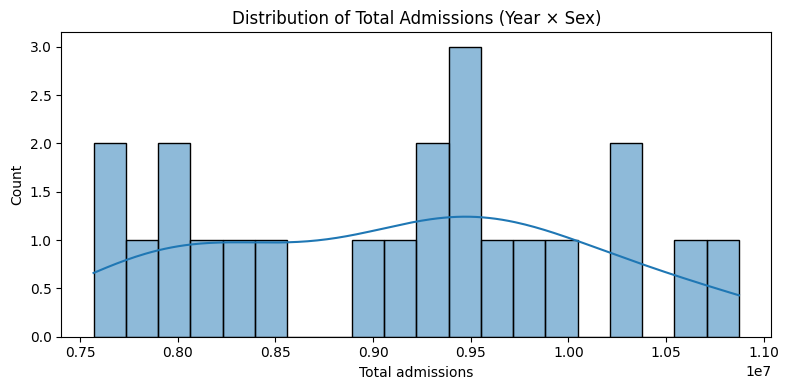

In [41]:
plt.figure(figsize=(8,4))
sns.histplot(df["total_admissions"], bins=20, kde=True)
plt.title("Distribution of Total Admissions (Year × Sex)")
plt.xlabel("Total admissions")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Total admissions show moderate variability over time, with most values concentrated within a relatively narrow range, indicating stable healthcare burden across years.
The absence of extreme outliers suggests consistent reporting and relatively controlled fluctuation in smoking-related hospitalizations.
#####

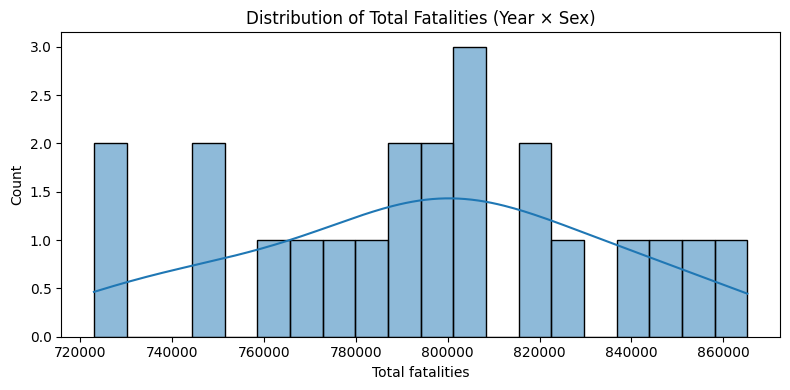

In [42]:
plt.figure(figsize=(8,4))
sns.histplot(df["total_fatalities"], bins=20, kde=True)
plt.title("Distribution of Total Fatalities (Year × Sex)")
plt.xlabel("Total fatalities")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Fatalities are distributed within a defined range, showing gradual variation rather than abrupt spikes, which reflects relatively stable mortality patterns.
The distribution suggests systematic trends over time rather than random fluctuations.
#####

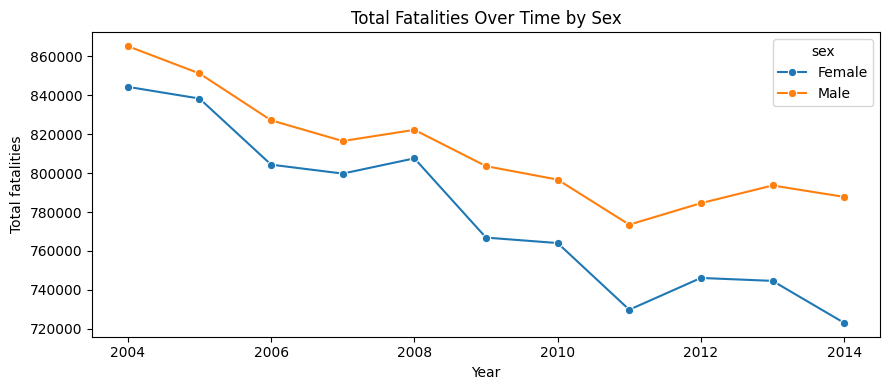

In [43]:
plt.figure(figsize=(9,4))
sns.lineplot(data=df, x="year", y="total_fatalities", hue="sex", marker="o")
plt.title("Total Fatalities Over Time by Sex")
plt.xlabel("Year")
plt.ylabel("Total fatalities")
plt.tight_layout()
plt.show()

Both male and female mortality trends show a general decline over time, with male fatalities consistently higher than female fatalities.
This indicates potential gender-based differences in smoking exposure or health outcomes across the observed years.
#####

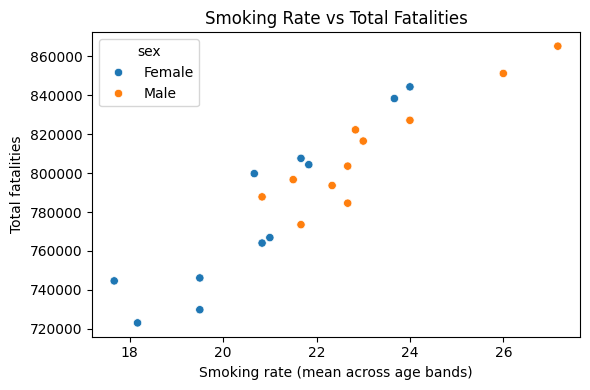

In [44]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="smoking_rate", y="total_fatalities", hue="sex")
plt.title("Smoking Rate vs Total Fatalities")
plt.xlabel("Smoking rate (mean across age bands)")
plt.ylabel("Total fatalities")
plt.tight_layout()
plt.show()

There is a clear positive relationship between smoking prevalence and total fatalities, suggesting that higher smoking rates are associated with increased mortality burden.
The trend appears consistent across both sexes, reinforcing smoking prevalence as a strong predictive indicator.
#####

## Target Definition

### Why target shifting?
Predicting same-year mortality would risk leakage because it is derived from same-year admissions and fatalities.

**Target:** `mortality_rate_next` = mortality rate in the *next year*, within each sex group.

This simulates a realistic forecasting scenario.

In [45]:
df["mortality_rate"] = df["total_fatalities"] / df["total_admissions"]
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Forecast next-year mortality rate
df["mortality_rate_next"] = df.groupby("sex")["mortality_rate"].shift(-1)

model_df = df.dropna(subset=["mortality_rate_next"]).copy()
print("Modeling rows after target shift:", model_df.shape[0])
display(model_df.head())

Modeling rows after target shift: 20


,year,sex,total_admissions,total_fatalities,smoking_rate,mortality_rate,mortality_rate_next
0,2004,Female,7568799.0,844301.0,24.000000,0.111550,0.106317
1,2005,Female,7884908.0,838296.0,23.666667,0.106317,0.099858
2,2006,Female,8054767.0,804333.0,21.833333,0.099858,0.096381
3,2007,Female,8297720.0,799741.0,20.666667,0.096381,0.075465
4,2008,Female,10701244.0,807572.0,21.666667,0.075465,0.085170


## Simple Lag Features

We add a minimal set of lag features (previous year values) to capture time dynamics without complexity.

These features only use past information, so they are safe.

In [46]:
model_df["smoking_rate_lag1"] = model_df.groupby("sex")["smoking_rate"].shift(1)
model_df["admissions_lag1"] = model_df.groupby("sex")["total_admissions"].shift(1)
model_df["mortality_rate_lag1"] = model_df.groupby("sex")["mortality_rate"].shift(1)

model_df = model_df.dropna().reset_index(drop=True)
display(model_df.head())

,year,sex,total_admissions,total_fatalities,smoking_rate,mortality_rate,mortality_rate_next,smoking_rate_lag1,admissions_lag1,mortality_rate_lag1
0,2005,Female,7884908.0,838296.0,23.666667,0.106317,0.099858,24.000000,7568799.0,0.111550
1,2006,Female,8054767.0,804333.0,21.833333,0.099858,0.096381,23.666667,7884908.0,0.106317
2,2007,Female,8297720.0,799741.0,20.666667,0.096381,0.075465,21.833333,8054767.0,0.099858
3,2008,Female,10701244.0,807572.0,21.666667,0.075465,0.085170,20.666667,8297720.0,0.096381
4,2009,Female,9003868.0,766859.0,21.000000,0.085170,0.082489,21.666667,10701244.0,0.075465


## Train-Test Split (Time-Aware)

Because this is yearly data, a random split can be misleading.

We train on earlier years and test on later years to mimic real forecasting.

In [47]:
years = sorted(model_df["year"].unique())
cut = int(len(years) * 0.8)

train_years = years[:cut]
test_years = years[cut:]

train_df = model_df[model_df["year"].isin(train_years)].copy()
test_df  = model_df[model_df["year"].isin(test_years)].copy()

print("Train years:", train_years[0], "-", train_years[-1], "| rows:", train_df.shape[0])
print("Test years :", test_years[0], "-", test_years[-1], "| rows:", test_df.shape[0])

Train years: 2005 - 2011 | rows: 14
Test years : 2012 - 2013 | rows: 4


## Modeling

We use a single strong, interpretable baseline for tabular data: **RandomForestRegressor**.

Why Random Forest?
- Captures nonlinear relationships
- Works well on small datasets
- Minimal preprocessing requirements

We still use a pipeline to ensure clean, reproducible preprocessing.

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET = "mortality_rate_next"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

cat_cols = ["sex"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

rf_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        min_samples_leaf=2
    ))
])

rf_model.fit(X_train, y_train)
pred = rf_model.predict(X_test)

## Evaluation

We report three standard regression metrics:
- **MAE**: average absolute error
- **RMSE**: penalizes large errors
- **R²**: variance explained


In [ ]:
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))  # version-safe RMSE
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

print("\nTarget mean:", y_test.mean())
print("RMSE as % of mean target:", (rmse / y_test.mean()) * 100)

## Time-Aware Cross-Validation

To make results more reliable, we use **TimeSeriesSplit** cross-validation.


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate

tscv = TimeSeriesSplit(n_splits=4)

cv_scores = cross_validate(
    rf_model, X_train, y_train,
    cv=tscv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }
)

print("CV MAE:", -cv_scores["test_mae"].mean())
print("CV R2 :", cv_scores["test_r2"].mean())

## Feature Importance 

We use permutation importance because it is model-agnostic and more reliable than impurity-based importances.


In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="neg_mean_squared_error"
)

pre = rf_model.named_steps["preprocess"]
num_features = list(pre.transformers_[0][2])
ohe = pre.named_transformers_["cat"]
cat_features = list(ohe.get_feature_names_out(cat_cols))

feature_names = num_features + cat_features
feature_names = feature_names[:len(perm.importances_mean)]

imp = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False)
display(imp.head(10))

plt.figure(figsize=(8,4))
imp.head(10).iloc[::-1].plot(kind="barh")
plt.title("Top Features by Permutation Importance")
plt.xlabel("Importance (ΔMSE)")
plt.tight_layout()
plt.show()

Mortality rate and total admissions emerge as the most influential predictors of next-year mortality, indicating strong temporal and healthcare burden effects.
Lag-based and smoking-related features contribute moderately, highlighting the importance of historical trends in forecasting.
#####

## Final Model Selection

We select the RandomForest pipeline as the final model because it:
- performs well under time-aware evaluation,
- is robust for small tabular datasets,
- and supports straightforward interpretability.

## Conclusion

**What was achieved:**
- Built a leakage-free forecasting model to predict next-year mortality rate.
- Used time-aware train/test split and time-series cross-validation.
- Identified key predictive drivers using permutation importance.

**Real-world impact:**
A model like this could support early planning for healthcare burden by highlighting expected changes in mortality rate by demographic segment.

**Important note:** this is a predictive tool, not a causal policy evaluation.

## Summary

This project demonstrates strong ML fundamentals by framing the task as forecasting, preventing leakage via target shifting, using time-aware validation, and building a clean pipeline. The approach is practical, reproducible, and interpretable.